# Monte Karlo simulacije

**Šta su Monte Karlo simulacije?**

Monte Karlo simulacija, takođe poznata kao Monte Karlo metoda ili simulacija višestruke verovatnoće, je matematička tehnika koja se koristi za procenu mogućih ishoda neizvesnog događaja. Metodu Monte Karla izmislili su Džon fon Nojman i Stanislav Ulam tokom Drugog svetskog rata da bi poboljšali donošenje odluka u neizvesnim uslovima. Ime je dobio po poznatom kazino gradu, zvanom Monte Karlo, pošto je element slučajnosti jezgro modela modela, slično u igri rulet.

Od svog uvođenja, Monte Karlo metod je procenio uticaj rizika u mnogim scenarijima iz stvarnog života, kao što su veštačka inteligencija, cene akcija, predviđanje prodaje, upravljanje projektima i određivanje cena. On takođe pruža brojne prednosti u odnosu na prediktivne modele sa fiksnim ulazima, kao što je mogućnost sprovođenja analize osetljivosti ili izračunavanja korelacije inputa. Analiza osetljivosti omogućava donosiocima odluka da vide uticaj pojedinačnih inputa na dati ishod, a korelacija im omogućava da razumeju odnose između bilo koje ulazne promenljive.

**Kako funkcioniše metod Monte Karlo?** Za razliku od klasičnog modela predviđanja, gde imamo fiksirane ulazne vrednosti, Monte Karlo simulacija predviđa skup ishoda na osnovu vrednosti čija je karakteristika slučajnost. Drugim rečima, Monte Karlo simulacija gradi model mogućih rezultata korišćenjem raspodele verovatnoća, kao što je uniformna ili normalna raspodela, za bilo koju promenljivu koja ima inherentnu nesigurnost. Zatim ponovo i iznova izračunava rezultate, svaki put koristeći drugačiji skup slučajnih brojeva iz istih raspodela verovatnoća. U tipičnom Monte Karlo eksperimentu, ova vežba se može ponoviti hiljade puta da bi se proizveo veliki broj verovatnih ishoda.

Monte Karlo simulacije se takođe koriste za dugoročna predviđanja zbog svoje tačnosti. Kako se broj ulaznih podataka povećava, raste i broj predviđanja, što vam omogućava da projektujete rezultate dalje u vremenu sa više tačnosti. Kada je Monte Karlo simulacija završena, ona daje raspodelu verovatnoća nad skupom ishoda.

**Koji su osnovni koraci u primeni Monte Karlo metoda?**  Bez obzira koji alat se koristi, Monte Karlo tehnika uključuja tri osnovna koraka:

- Postavite prediktivni model, identifikujući i zavisnu promenljivu koju treba predvideti i nezavisne promenljive (poznate i kao promenljive ulaza, rizika ili prediktora) koje će pokretati predviđanje.
- Odredite raspodele verovatnoća nezavisnih promenljivih. Koristite istorijske podatke i/ili subjektivnu procenu analitičara da biste definisali opseg verovatnih vrednosti i dodelili pondere verovatnoće za svaku.
- Pokrenite simulacije više puta, generišući nasumične vrednosti nezavisnih promenljivih. Uradite ovo dok se ne prikupi dovoljno rezultata da se napravi reprezentativan uzorak skoro beskonačnog broja mogućih kombinacija.

Možete pokrenuti onoliko Monte Karlo simulacija koliko želite tako što ćete modifikovati osnovne parametre koje koristite za simulaciju podataka. Međutim, takođe ćete želeti da izračunate opseg varijacije unutar uzorka tako što ćete izračunati varijansu i standardnu devijaciju, koje se obično koriste kao mere varijacije podataka. Obično se manja varijacija smatra boljom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

```{admonition} Primer 1. *Bacanje 3 kocke*
:class: tip

Bacamo tri kockice za igru i posmatramo ukupan zbir tačkica na gornjim stranama sve tri kocke. Odrediti raspodelu verovatnoća brojeva koji se mogu pojaviti kao zbir.
```

Prvo ćemo konstruisati funkciju koja simulira jedno bacanje.

In [8]:
def bacanje_3k():
    return np.random.randint(1,7)+np.random.randint(1,7)+np.random.randint(1,7)

Testirajmo sada funkciju koja simulira jedno bacanje:

In [11]:
for i in range(25):
    print(bacanje_3k(),end='  ')    

9  17  7  10  9  10  16  13  11  9  11  8  16  10  10  7  7  11  12  11  11  13  10  12  8  

Sad kreirajmo slučajni uzorak obima $n=10,000$

In [14]:
n=10**5
simulacije = [bacanje_3k() for i in range(n)]

Kreirajmo DataFrame objekat koji sadrži simulacije kako bi lakše napravili analizu (imamo više metoda).

In [16]:
df=pd.DataFrame(simulacije)

In [18]:
raspodela_3k = df.value_counts(sort = False, normalize =True)

In [20]:
raspodela_3k = pd.DataFrame({'Verovatnoća': raspodela_3k.values}, index=range(3,19))
raspodela_3k.index.rename('Zbir', inplace = True)

Raspodela verovatnoća nad mogućim zbirovima je sada:

In [20]:
print(raspodela_3k)

      Verovatnoća
Zbir             
3         0.00482
4         0.01370
5         0.02696
6         0.04565
7         0.06959
8         0.09817
9         0.11460
10        0.12515
11        0.12511
12        0.11666
13        0.09575
14        0.06960
15        0.04659
16        0.02874
17        0.01395
18        0.00496


In [ ]:
Na kraju, možemo raspodelu prikazati i grafički stubičastim dijagramom:

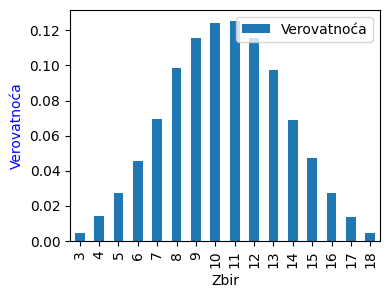

In [23]:
fig, ax1 = plt.subplots(figsize=(4,3))
ax1.set_ylabel('Verovatnoća', color='blue')
ax1.set_xlabel('Zbir')
raspodela_3k.plot.bar(ax=ax1)
plt.show()

```{admonition} Primer 2. *Aukcija*
:class: tip

Osoba A vrednuje antikvarni predmet 110 (u hiljadama dolara). Pored osobe A na aukciji učestvuju još osobe B i C. Vrednost koju osoba B dodeljuje predmetu aukcije je slučajna veličina sa diskretnom uniformnom raspodelom na intervalu od 90 do 115, a  vrednost koju osoba C dodeljuje predmetu aukcije je slučajna veličina sa diskretnom uniformnom raspodelom na intervalu od 80  do 115. Pretpostavimo da na aukciji predmet dobija osoba koja ponudi najvišu cenu  i da onda plaća za predmet drugu najvišu cenu.

- Napravite simulacije aukcije i odredite očekivani profit osobe A, kao i standardnu devijaciju tog profita, ako je osoba odlučila da licitira 110. 
- Pretpostavite sada da osoba A razmatra redom licitacije od 80 do 115 (samo iznose u celim brojevima). Odredite optimalnu strategiju, primenom simulacija, ako je kriterijum očekivani profit. 

**Konstrukcija modela.**

Sledeća funkcija simulira jednu aukciju:

In [25]:
def aukcija(b_0= 100, v_0=110, a_1=90, b_1=115, a_2=80, b_2=115):
    """
    Funkcija simulira jednu aukciju po drugoj najvišoj ceni sa tri učesnika iz aspekta prvog učesnika.
    Promenljive:
    b_0 - koliko će osoba A licitirati
    v_0 - koliko osoba A vrednuje predmet
    a_1, b_1 - parametri raspodele (uniformne) vezani za osobu B
    a_2, b_2 - parametri raspodele (uniformne) vezani za osobu C
    """
    
    licitacije=[b_0]                                        # licitacija A
    licitacije.append(np.random.uniform(a_1,b_1))           # Licitacija B
    licitacije.append(np.random.uniform(a_2,b_2))           # Licitacija C 
    if sorted(licitacije, reverse=True)[0]==licitacije[0]:        # Da li je pobednik aukcije A?
        return round(v_0 - sorted(licitacije, reverse=True)[1],2) # Ako jeste koliko je njegov dobitak ?
    else:
        return 0                                                    

Testirajmo sada našu funkciju:

In [28]:
for i in range(10):
    print(aukcija(), end='  ')

0  0  0  0  10.04  0  0  0  0  0  

Simulirajmo aukciju veliki broj puta.

In [30]:
n=10**5
simulacije = pd.Series([aukcija() for i in range(n)])

**Analiza dobijenih rezultata**

In [33]:
print(f'Aritmetička sredina: {simulacije.mean():.2f}')
print(f'Standardna devijacija: {simulacije.std():.2f}')

Aritmetička sredina: 3.25
Standardna devijacija: 6.10


Prikažimo rezultate histogramom:

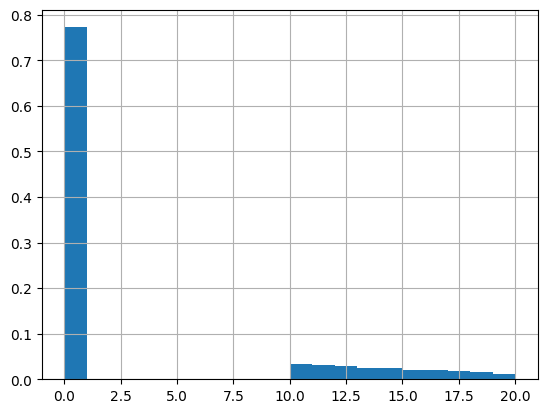

In [24]:
simulacije.hist(bins=20, density=True);

Da li odavde možemo nešto da zaklučimo? Skoro ništa, sem da je očekivani dobitak relativno skroman i sa relativno veliko varijansom.

Povodom toga možemo da pokrenemo drugi element simulacija, a to je analiza osetljivosti. U tom smislu, variraćemo moguće licite prve osobe u rasponu od 80 do 115 (takve licitacije imaju smisla s obzirom na raspodele drugih učesnika) i ocenjivaćemo ih sa srednjim dobitkom.

In [28]:
n=10**5
akcije =[np.array([aukcija(bid) for i in range(n)]).mean() for bid in range(80,116)] 

Pogledajmo sada stubičasti dijagram ocena licita:

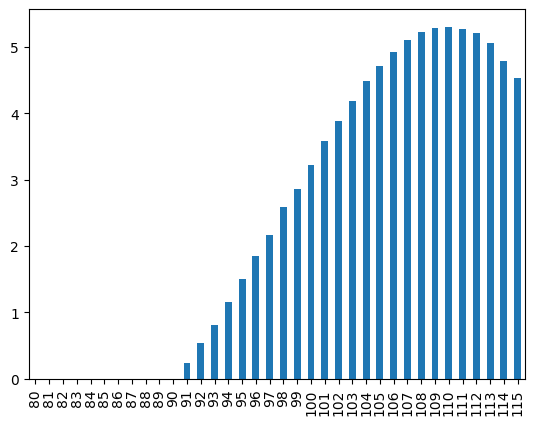

In [29]:
akcije=pd.Series(akcije, index=np.arange(80,116))
akcije.plot.bar();

Ako nas interesuje najbolja akcija u tom smislu:

In [34]:
print(f'Najbolji licit je {80+akcije.argmax()}.')

Najbolji licit je 110


Rezultat je se poklapa sa onim što kaže teorija u slučaju uniformnih raspodela ostalih aukcionara, a to je da je najbolja straegija onoliko koliko vrednujemo predmet. Prednost simulacija je to što možemo koristiti i druge raspodele za koje teorija ne daje optimalan licit.

```{admonition} Primer 3. *Dan zaljubljenih* 
:class: tip
Pretpostavimo da se tražnja za razglednicama na Dan zaljubljenih može opisati diskretnom slučajnom promenljivom:
:::{table} Raspodela verovatnoća tražnje
:class: thin
:label: sim_p3
:align: center

| Tražnja       | $10,000$ | $20,000$ | $40,000$ | $60,000$ |
|:-----------------------|:----------:|:----------:|:----------:|:----------:|
| Verovatnoća | $0.1$    | $0.35$   | $0.3$    | $0.25$   |
:::

Čestitke se prodaju po 4$\$$, a varijabilni troškovi za proizvodnju jedne čestitke su 1.5$\$$. Neprodate čestitke se moraju ukloniti i cena te operacije je 0.2$\$$ po čestitci. Koliko čestitki treba odštampati?
```

**Konstrukcija modela.**

Prvo ćemo konstruisati funkciju koja računa profit za fiksirane vrednosti parametara.

In [3]:
def profit(s, d, p = 4, vc = 1.5, c= 0.2):
    """
    Funkcija računa profit u zavisnosti od tražnje i nabavne količine
    
    Promenljive:
    p - prodajna cena čestittki
    vc - varijablini troškovi proizvodnje
    c - troškovi reciklaže
    s - ponuda
    d - tražnja (Slučajna promenljiva)
    """
    
    if s < d:
        profit = s*p - s*vc
    else:
        profit = d*p - s*vc - (s-d)*c
    return profit

In [5]:
# Testiranje 1
profit(10000, 30000) 

25000.0

In [7]:
# Testiranje 2
profit(50000, 30000) 

41000.0

**Generisanje uzorka i vrednosti za ispitivanje osetljivosti.**

In [10]:
traznja = np.random.choice([10000, 20000, 40000, 60000], size=10000, replace=True, p=[0.1, 0.35, 0.3, 0.25]) # uzorak

In [12]:
ponuda = [10000, 20000, 40000, 60000] # Vrednosti ponude za testiranje osetljivosti

In [14]:
profit_multi = [ [profit(s, d) for s in ponuda] for d in traznja]
df_profit = pd.DataFrame(profit_multi, columns=['p_10000', 'p_20000', 'p_40000', 'p_60000'])
df_profit.head()

,p_10000,p_20000,p_40000,p_60000
0,25000.0,50000.0,16000.0,-18000.0
1,25000.0,50000.0,100000.0,150000.0
2,25000.0,50000.0,100000.0,66000.0
3,25000.0,50000.0,16000.0,-18000.0
4,25000.0,50000.0,16000.0,-18000.0


**Analiza rezultata.**

In [17]:
df_profit.describe()

,p_10000,p_20000,p_40000,p_60000
count,10000.0,10000.000000,10000.000000,10000.000000
mean,25000.0,45808.400000,58336.000000,45596.400000
std,0.0,12589.421702,47877.530531,73471.246821
min,25000.0,8000.000000,-26000.000000,-60000.000000
25%,25000.0,50000.000000,16000.000000,-18000.000000
50%,25000.0,50000.000000,100000.000000,66000.000000
75%,25000.0,50000.000000,100000.000000,150000.000000
max,25000.0,50000.000000,100000.000000,150000.000000


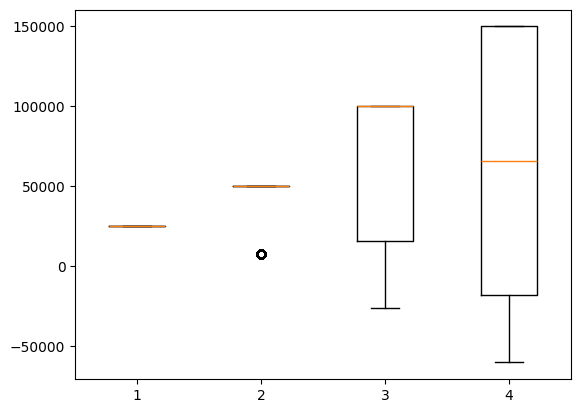

In [78]:
plt.boxplot(df_profit)
plt.show()

**Zaključak.**
Zavisi od rizika: 
- veća sklonost riziku  ... štampanje 60000
- manja sklonost riziku  ... štampanje 40000

```{admonition} Primer 3. *Dan zaljubljenih* 
:class: tip

*Sanatronics* je kompanija koja proizvodi medicinske uređaje za bolničke klinike. Inspirisani članovima porodice koji se bore sa kancerom, osnivači *Sanatronics*-a razvili su prototip novog uređaja koji ograničava izloženost medicinskih radnika u toku tretmana hemoterapijom dok pripremaju, administriraju i ukljanjaju ove opasne medikamente. Nov uređaj ima inovativni dizajn i potencijalno ozbiljnu mogućnost da pokrije veliki deo tržišta.

*Sanatronics* želi da analizira potencijal profita u prvoj godini. Zbog loše situacije sa gotovinom, mendžment je posebno oprezan u vezi mogućih gubitaka. *Sanatronics* je identifikovao ključne parametre u određivanju profita u toku prve godine: prodajna cena po jedinici ($p$), administrativni troškovi i troškovi reklamiranja u toku prve godine ($c_a$), troškovi rada po jedinici ($c_r$), troškovi za delove po jedinici ($c_d$) i tražnja ($d$) u toku prve godine. Posle sprovedenog istraživanja tržišta i finansijske analize, *Sanatronics* je procenio sa velikim nivoom sigurnosti da će prodajna cena biti 249$\$$ po jedinici kao i da će administrativni toškovi i troškovi reklamiranja u toku prve godine iznositi ukupno 1,000,000$\$$. *Sanatronics* nije siguran o vrednostima troškova rada, delova i tražnje. 

Napraviti Monte Karlo simulaciju za problem *Sanatronics*-a pod sledećim pretpostavkama:
- Troškovi rada po jedinici ($c_r$) su slučajna promenljiva sa raspodelom 
$$c_r:\begin{pmatrix} 43 & 44 & 45 & 46 & 47 \\ 0.1 & 0.2 & 0.4 & 0.2 & 0.1 \end{pmatrix} $$
- Troškovi za delove po jedinici ($c_d$) su slučajna promenljiva sa raspodelom: $\mathcal{U}(80,100)$
- Tražnja ($d$) u toku prve godine je slučajna promenljiva sa raspodelom: $\mathcal{N}(15000,4500)$
```

**Model.**

In [56]:
def sanatronics(c_r, c_d, d, p = 249, c_a = 1000000):
    """
    Funkcija računa profit u zavisnosti od cena rada po jedinici, troškova delova po jedinici i tražnje
    
    Promenljive:
    p - prodajna cena 
    c_a - administrativni troškovi i troškovi reklamiranja
    c_r - troškovi rada po jedinici
    c_d - troškovi delova po jedinici
    d - tražnja
    """
    
    # Prihod
    R = d*p
    # Fiksni troškovi
    FC = c_a 
    #Varijablini troškovi
    VC = d*(c_r+c_d)
    
    #Profit
    P = R-VC-FC
    return P

#### Testiranje

In [57]:
sanatronics(43,80,15000)

890000

**Simulacije.**

In [58]:
n = 10000 # Veličina uzorka
c_r = np.random.choice(np.arange(43,48), size=n, replace=True, p=[0.1, 0.2, 0.4, 0.2, 0.1])
c_d = np.random.uniform(80,100, size =n)
d   = np.random.normal(15000,4500, size=n)

In [59]:
df_sanatronics_profit = pd.Series(sanatronics(c_r, c_d, d))

**Analiza rezultata.**

In [60]:
df_sanatronics_profit.describe()

count    1.000000e+04
mean     7.194105e+05
std      5.179511e+05
min     -1.138046e+06
25%      3.723988e+05
50%      7.169230e+05
75%      1.060767e+06
max      2.825412e+06
dtype: float64

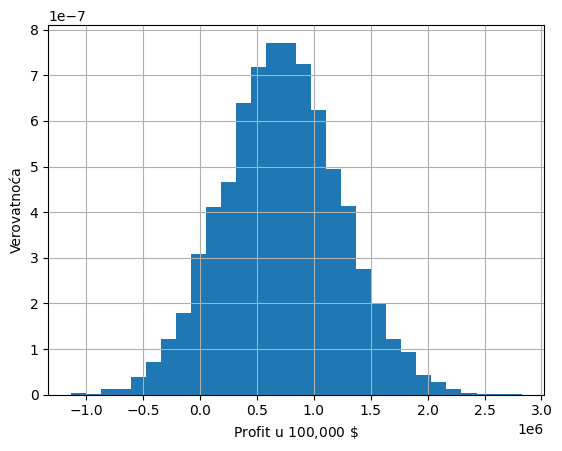

In [61]:
fig, ax = plt.subplots()
df_sanatronics_profit.hist(ax=ax, bins=30, density=True)
plt.ylabel("Verovatnoća")
plt.xlabel("Profit u 100,000 $\$$")
plt.show()

In [62]:
np.count_nonzero(df_sanatronics_profit<0)/n  #Verovatnoća da će profit biti manji od nule

0.083

### Zaključak

Očekivani profit od preko 700,000$\$$ i jako mala verovatnoća gubitka sugerišu ulazak u posao.

<style>

/* bold i veći brojevi */
.text_cell_render ol > li::marker {
  font-weight: 900;
  font-size: 1.7em;
}

/* VELIKI razmak između zadataka */
.text_cell_render ol > li {
  margin-top: 2.8em !important;
  margin-bottom: 2.8em !important;
  line-height: 1.45 !important;
}

/* PODLISTA — kompresovana */
.text_cell_render ol > li > ul > li {
  margin-top: 0 !important;
  margin-bottom: 0 !important;
  line-height: 0.95 !important;
}

</style>

## Zadaci i problemi


#### ⚡️ Zadatak 1.

Kompanija Trayal u svrhu promocije nudi 1 evro za svakih započetih 100 kilometara ako životni vek nove gume bude ispod 30,000 kilometara. Menadžment kompanije veruje da je životni vek najnovije gume slučajna promenljiva raspodelom $\mathcal N (35000,5000^2)$. Primer: Neka je guma prešla 29356 kilometara. Kako je $30000-29356=644$, kompanija će nadoknaditi 7 evra.
- Koliki su prosečni troškovi ove promocije po jednoj gumi?  
- Kolika je verovatnoća da će trošak promocije po jednoj gumi biti preko 50 evra?

#### ⚡️ Zadatak 2.

Konstruišite simulacioni model koji generiše uzorak veličine 1000 iz normalne raspodele $\mathcal{N}(5, 2)$. Na osnovu prethodnog uzorka konstruišite histogram sa 12 stubića.


#### ⚡️ Zadatak 3.

Pretpostavi da je kvartalni rast realnog BDP-a dat kao $ g_t = \mu + \varepsilon_t $, gde je $\mu=0.6\%$ po kvartalu, a $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ sa $\sigma=0.8\%$.

- Simuliraj 10.000 puteva rasta za 4 kvartala i izračunaj godišnji rast kao $ \left(\prod_{t=1}^4 \left(1+\frac{g_t}{100}\right) - 1\right) \cdot 100 $.  
- Prikaži prosečan godišnji rast.

#### ⚡️ Zadatak 4.

Kompanija **FitCloud** razvila je mobilnu aplikaciju za praćenje fizičke aktivnosti. Aplikacija je besplatna, ali deo korisnika prelazi na **premium plan**, čime ostvaruje prihod.  
Menadžment želi da proceni kretanje broja korisnika i prihoda tokom narednih 12 meseci.

Tvoj zadatak je da napišeš program koji će **simulirati rast korisnika i mesečni prihod** odaplikacije, koristeći jednostavan probabilistički model.

Pravila i pretpostavke modela

- Početni broj korisnika: `U0`  
- Svakog meseca aplikacija dobija nove korisnike (`new_users`) nasumično između **min_new** i **max_new**.  
- Deo korisnika prelazi na **premium plan** sa verovatnoćom `p_premium`.  
- Mesečni prihod se računa po formuli:  `prihod = premium_users * avg_revenue_per_user`  
- Deo korisnika mesečno napušta aplikaciju (**churn**) sa verovatnoćom `p_churn`.  
- Simulacija traje 12 meseci (ili `months` ako se navede druga vrednost).

Napisati funkciju:

```python
def fitcloud_simulation(U0, min_new, max_new, p_premium, p_churn, avg_revenue_per_user, months=12):
    """
    Simulira rast korisnika i prihod aplikacije tokom 'months' meseci.
    Vraća listu tuple-ova:
    [(mesec, ukupno_korisnika, premium_korisnici, prihod_usd), ...]
    """